# 沃尔玛销售数据
walmart_stores_data.csv 
简介：数据集包含沃尔玛的销售数据。沃尔玛全国范围内有多家零售门店在库存管理方面的问题，那么如何将供应与需求相匹配呢？作为一名数据科学家，你可  以利用数据，提供有用的见解，并创建预测模型，从而能预测未来X个月/年的销售情况。
变量含义：
- Store：店铺编号
- Date：销售周
- Weekly_Sales：店铺在该周的销售额
- Holiday_Flag：是否为假日周
- Temperature：销售日的温度
- Fuel_Price：该地区的燃油成本
- CPI（消费者物价指数）：消费者物价指数
- Unemployment：失业率

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("walmart_stores_data.csv")
original_data.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [3]:
cleaned_data = original_data.copy()
cleaned_data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
cleaned_data['Date'] = pd.to_datetime(cleaned_data['Date'],format='%d-%m-%Y')
cleaned_data['Date']

0      2010-02-05
1      2010-02-12
2      2010-02-19
3      2010-02-26
4      2010-03-05
          ...    
6430   2012-09-28
6431   2012-10-05
6432   2012-10-12
6433   2012-10-19
6434   2012-10-26
Name: Date, Length: 6435, dtype: datetime64[ns]

In [6]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [7]:
cleaned_data.duplicated(subset=['Store', 'Date']).sum()

0

In [8]:
cleaned_data.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21806 (\N{

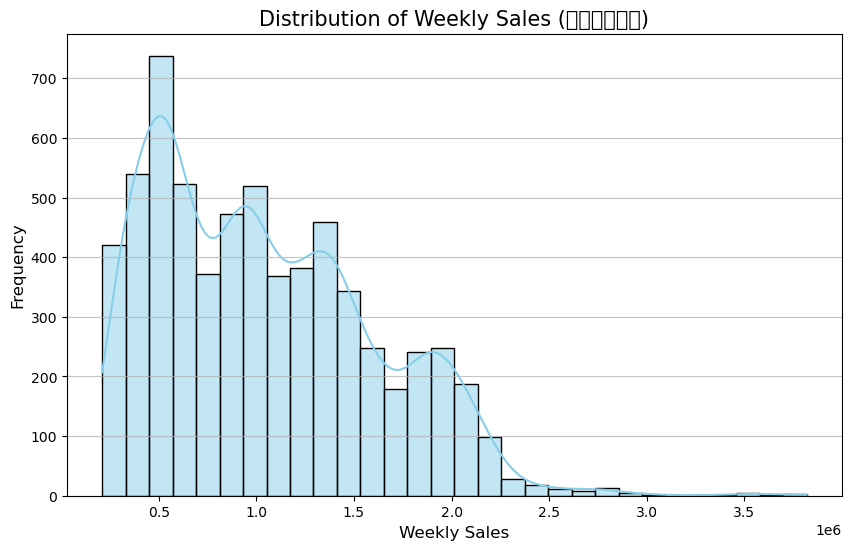

偏度 (Skewness): 0.67


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_data['Weekly_Sales'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Weekly Sales (周销售额分布)', fontsize=15)
plt.xlabel('Weekly Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# 打印偏度
print(f"偏度 (Skewness): {cleaned_data['Weekly_Sales'].skew():.2f}")

d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\L

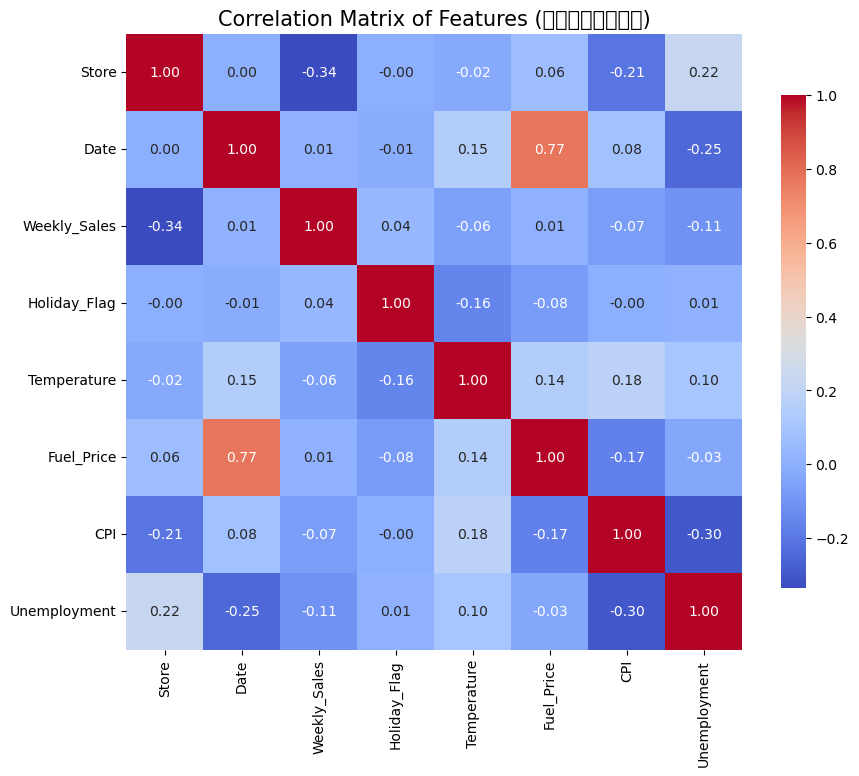

In [10]:
plt.figure(figsize=(10, 8))
# 计算相关系数矩阵
correlation_matrix = cleaned_data.corr()

# 绘制热力图
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features (特征相关性热力图)', fontsize=15)
plt.show()

d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20551 (\N{CJK UNIFIED IDEOGRAPH-5047}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pyla

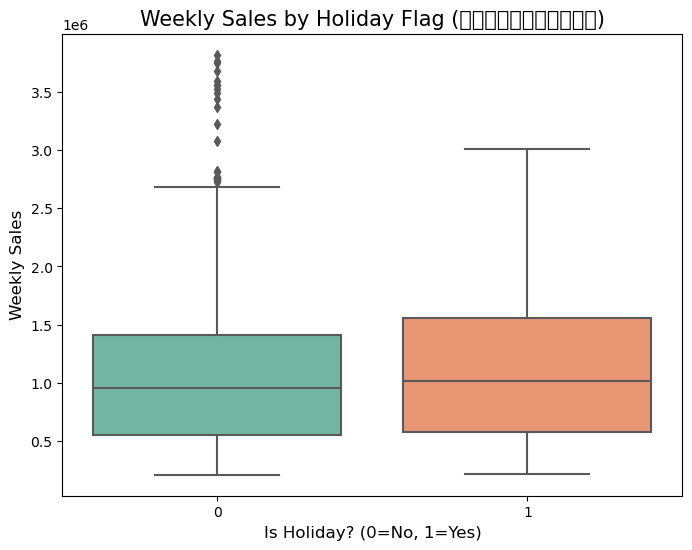

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=cleaned_data, palette='Set2')
plt.title('Weekly Sales by Holiday Flag (假日与非假日销售额对比)', fontsize=15)
plt.xlabel('Is Holiday? (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.show()

d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\users\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39069 (\N{CJK UNIFIE

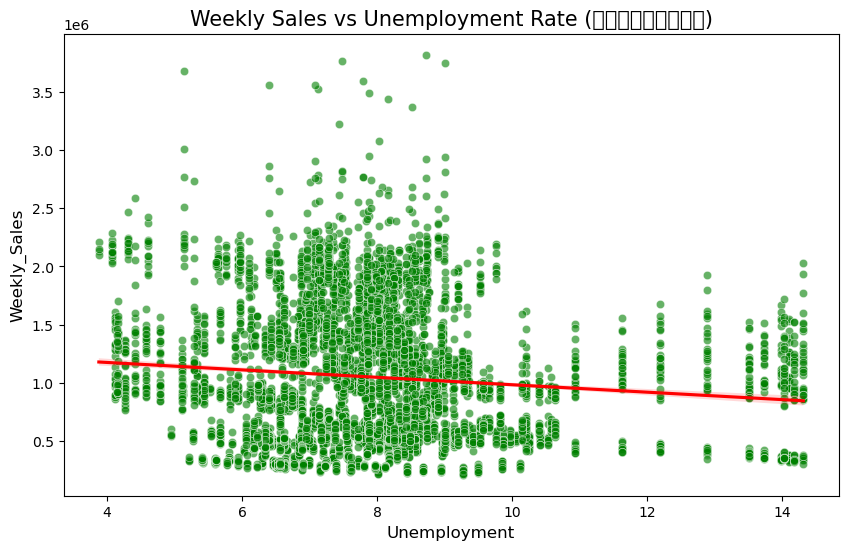

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=cleaned_data, alpha=0.6, color='green')
plt.title('Weekly Sales vs Unemployment Rate (销售额与失业率关系)', fontsize=15)
plt.xlabel('Unemployment Rate', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
# 添加趋势线
sns.regplot(x='Unemployment', y='Weekly_Sales', data=cleaned_data, scatter=False, color='red')
plt.show()

已自动提取 'Month' 列。


C:\Users\goy\AppData\Local\Temp\ipykernel_10912\3334695354.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='Month', y='Weekly_Sales', data=cleaned_data, ci=None)
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\

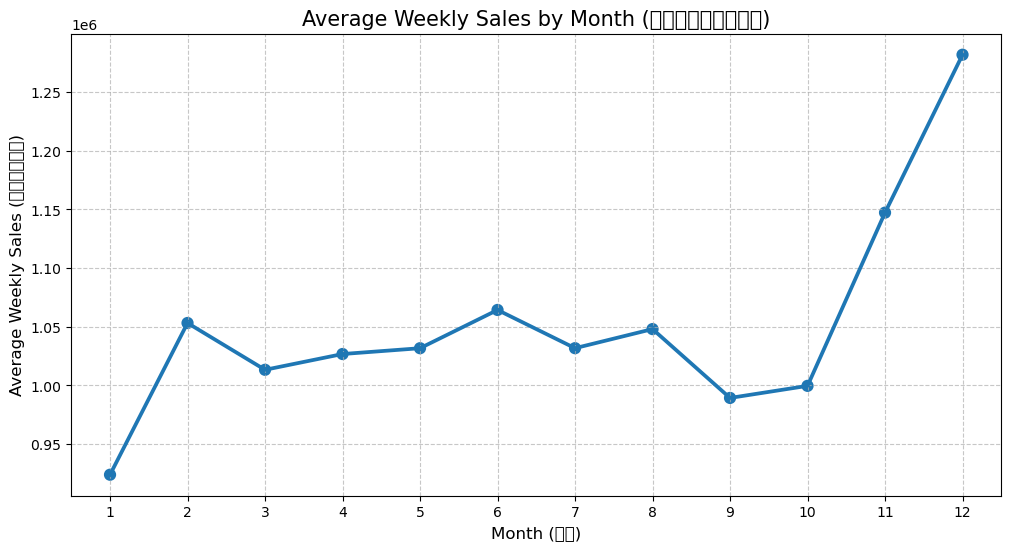

In [13]:
if 'Month' not in cleaned_data.columns:
    cleaned_data['Date'] = pd.to_datetime(cleaned_data['Date'])
    cleaned_data['Month'] = cleaned_data['Date'].dt.month
    print("已自动提取 'Month' 列。")
plt.figure(figsize=(12, 6))
sns.pointplot(x='Month', y='Weekly_Sales', data=cleaned_data, ci=None)
plt.title('Average Weekly Sales by Month (各月平均销售额趋势)', fontsize=15)
plt.xlabel('Month (月份)', fontsize=12)
plt.ylabel('Average Weekly Sales (平均周销售额)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
# 导入标准缩放器
from sklearn.preprocessing import StandardScaler

# 1. 选择需要进行缩放的特征列
# 我们不缩放 'Weekly_Sales' (目标值)，也不缩放 'Date' (时间) 和 'Store' (ID)
# 我们只缩放影响销售的数值型特征
cols_to_scale = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# 2. 创建缩放器对象
scaler = StandardScaler()

# 3. 拟合并转换数据
# fit_transform 会计算均值方差并进行转换
cleaned_data[cols_to_scale] = scaler.fit_transform(cleaned_data[cols_to_scale])

# 4. 查看缩放后的结果
print("特征缩放已完成！以下是缩放后的数据预览：")
cleaned_data[cols_to_scale].head()

特征缩放已完成！以下是缩放后的数据预览：


,Temperature,Fuel_Price,CPI,Unemployment
0,-0.995136,-1.713800,1.004175,0.056964
1,-1.201170,-1.766089,1.007880,0.056964
2,-1.124178,-1.840166,1.009074,0.056964
3,-0.760907,-1.737766,1.009849,0.056964
4,-0.767955,-1.598328,1.010624,0.056964


In [15]:
# 导入拆分工具
from sklearn.model_selection import train_test_split

# 1. 定义特征 (X) 和 目标变量 (y)
# X 是我们用来做预测的依据（去掉日期和目标销售额）
# y 是我们要预测的目标（每周销售额）
X = cleaned_data.drop(['Weekly_Sales', 'Date'], axis=1)
y = cleaned_data['Weekly_Sales']

# 2. 进行拆分
# test_size=0.2 表示 20% 的数据作为测试集
# random_state=42 保证每次运行结果一致
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 打印拆分后的数据形状
print("训练集特征形状:", X_train.shape)
print("测试集特征形状:", X_test.shape)
print("训练集目标形状:", y_train.shape)
print("测试集目标形状:", y_test.shape)

训练集特征形状: (5148, 7)
测试集特征形状: (1287, 7)
训练集目标形状: (5148,)
测试集目标形状: (1287,)


In [16]:
# 导入随机森林回归模型
from sklearn.ensemble import RandomForestRegressor

# 1. 创建模型实例
# n_estimators=100: 表示建立100棵决策树（通常越多越准，但速度越慢）
# random_state=42: 保证结果可复现
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. 训练模型
# 使用训练集数据 (X_train) 和 真实销售额 (y_train) 来“教”模型
print("正在训练模型，请稍候...")
rf_model.fit(X_train, y_train)
print("模型训练完成！")

正在训练模型，请稍候...
模型训练完成！



===== 模型评估报告 =====
均方根误差 (RMSE): $139,698.33
平均绝对误差 (MAE): $72,287.58
决定系数 (R²): 0.9394
（R²越接近1表示模型解释力越强）


C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:29: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from cur

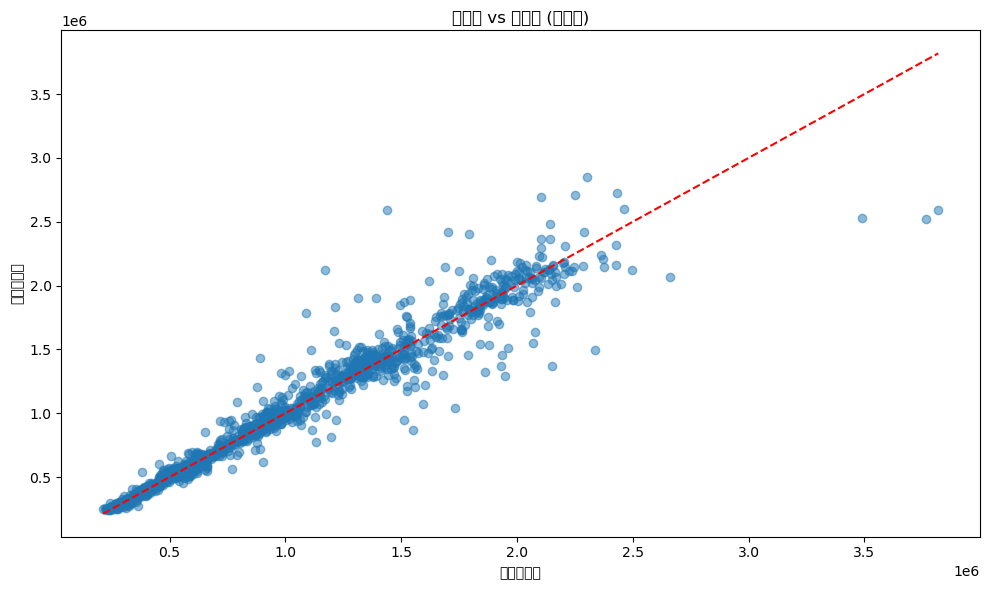

d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:39: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()
C:\Users\goy\AppData\Local\Temp\ipykernel_10912\1998585852.py:39: UserWarning:

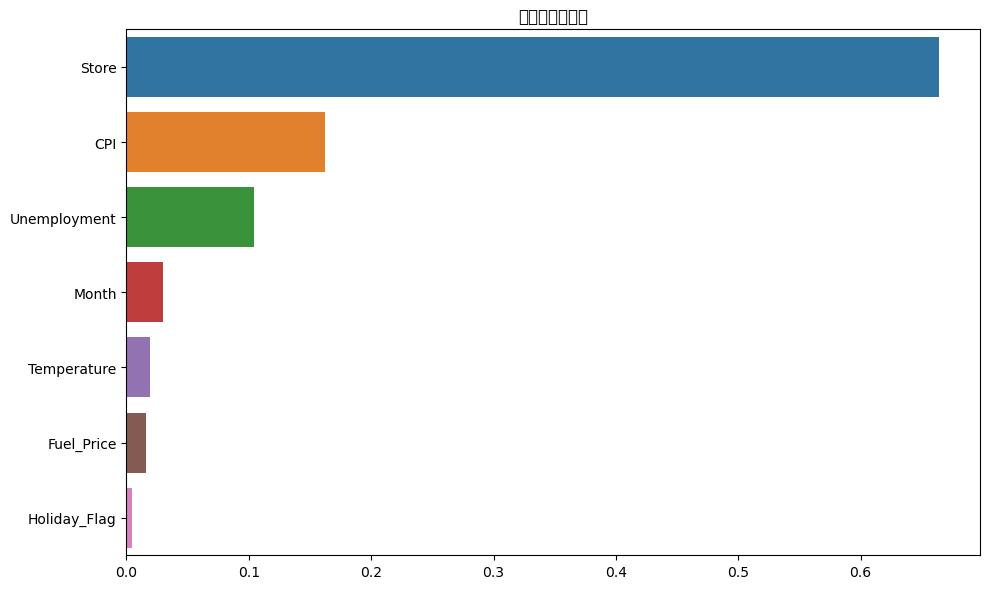


===== 关键发现 =====
对销售额影响最大的3个因素：
Store           0.664409
CPI             0.162064
Unemployment    0.103915


In [17]:
# 导入评估工具
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 用模型预测测试集
y_pred = rf_model.predict(X_test)

# 2. 计算关键评估指标
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # 均方根误差（与销售额单位一致）
mae = mean_absolute_error(y_test, y_pred)  # 平均绝对误差
r2 = r2_score(y_test, y_pred)  # 决定系数

print("\n===== 模型评估报告 =====")
print(f"均方根误差 (RMSE): ${rmse:,.2f}")
print(f"平均绝对误差 (MAE): ${mae:,.2f}")
print(f"决定系数 (R²): {r2:.4f}")
print(f"（R²越接近1表示模型解释力越强）")

# 3. 绘制预测值 vs 真实值对比图
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('真实销售额')
plt.ylabel('预测销售额')
plt.title('预测值 vs 真实值 (测试集)')
plt.tight_layout()
plt.show()

# 4. 分析特征重要性
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('特征重要性排名')
plt.tight_layout()
plt.show()

print("\n===== 关键发现 =====")
print("对销售额影响最大的3个因素：")
print(feature_importance.head(3).to_string())